### Build A Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]



In [26]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chat_models import init_chat_model

llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [6]:
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x00000185AF3074A0>, default_metadata=(), model_kwargs={})

In [12]:
## Node Functionality
def chatbot(state:State):
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages":[response]} # note the list

In [ ]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("chatbot",chatbot)

## Adding Edges
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

## compile the graph
graph=graph_builder.compile()

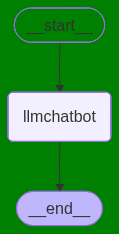

In [16]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png(background_color='green')))
except Exception:
    pass

In [17]:
response=graph.invoke({"messages":"Hi"})

In [19]:
response['messages'][-1].usage_metadata

{'input_tokens': 2,
 'output_tokens': 32,
 'total_tokens': 34,
 'input_token_details': {'cache_read': 0},
 'output_token_details': {'reasoning': 22}}

In [20]:
response["messages"][-1].content

'Hi there! How can I help you today?'

In [23]:
for event in graph.stream({'messages': "hi"}):
    for value in event.values():
        print(value['messages'][-1].content)

Hi there! How can I help you today?


### Chatbot With Tool

In [27]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph") 

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [28]:
## Custom function
def multiply(a:int, b:int) ->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [29]:
tools=[tool, multiply]

In [31]:
tools

[TavilySearch(max_results=2, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None)),
 <function __main__.multiply(a: int, b: int) -> int>]

In [30]:
llm_with_tool=llm.bind_tools(tools)

In [32]:
llm_with_tool

RunnableBinding(bound=ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x00000185AF3074A0>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, 

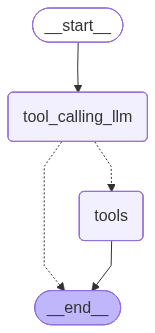

In [33]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [34]:
response=graph.invoke({"messages":"What is the weather today in pakistan"})

In [35]:
response['messages'][-1].content

'{"query": "weather today in Pakistan", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Weather in Pakistan", "url": "https://www.weatherapi.com/", "content": "{\'location\': {\'name\': \'Islamabad\', \'region\': \'Islamabad\', \'country\': \'Pakistan\', \'lat\': 33.7, \'lon\': 73.167, \'tz_id\': \'Asia/Karachi\', \'localtime_epoch\': 1781175640, \'localtime\': \'2026-06-11 16:00\'}, \'current\': {\'last_updated_epoch\': 1781174700, \'last_updated\': \'2026-06-11 15:45\', \'temp_c\': 42.5, \'temp_f\': 108.4, \'is_day\': 1, \'condition\': {\'text\': \'Sunny\', \'icon\': \'//cdn.weatherapi.com/weather/64x64/day/113.png\', \'code\': 1000}, \'wind_mph\': 13.0, \'wind_kph\': 20.9, \'wind_degree\': 240, \'wind_dir\': \'WSW\', \'pressure_mb\': 995.0, \'pressure_in\': 29.39, \'precip_mm\': 0.0, \'precip_in\': 0.0, \'humidity\': 9, \'cloud\': 8, \'feelslike_c\': 34.4, \'feelslike_f\': 93.9, \'windchill_c\': 42.5, \'windchill_f\': 108.4, \'heatindex_c\': 43.7, \

In [36]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the weather today in pakistan
================================== Ai Message ==================================
Tool Calls:
  tavily_search (1eac374d-fc39-4bcd-9c8b-1451a566b6ad)
 Call ID: 1eac374d-fc39-4bcd-9c8b-1451a566b6ad
  Args:
    query: weather today in Pakistan
================================= Tool Message =================================
Name: tavily_search

{"query": "weather today in Pakistan", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Weather in Pakistan", "url": "https://www.weatherapi.com/", "content": "{'location': {'name': 'Islamabad', 'region': 'Islamabad', 'country': 'Pakistan', 'lat': 33.7, 'lon': 73.167, 'tz_id': 'Asia/Karachi', 'localtime_epoch': 1781175640, 'localtime': '2026-06-11 16:00'}, 'current': {'last_updated_epoch': 1781174700, 'last_updated': '2026-06-11 15:45', 'temp_c': 42.5, 'temp_f': 108.4, 'is_day': 1, 'condition': {'tex

In [37]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (6339f556-1a09-435c-95d7-88f4dfa60526)
 Call ID: 6339f556-1a09-435c-95d7-88f4dfa60526
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [16]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (y5rf0ar1k)
 Call ID: y5rf0ar1k
  Args:
    query: recent ai news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bbc.com/news/articles/cn0q2v851k9o", "title": "Amazon boss says AI will replace jobs at tech giant - BBC", "score": 0.71995544, "published_date": "Tue, 17 Jun 2025 21:31:36 GMT", "content": "Companies, especially in the tech sector, have been investing heavily in AI in recent years, spurred on by technological advances that have made it easier than ever for chatbots to create code, images and text with

### ReAct Agent Architecture

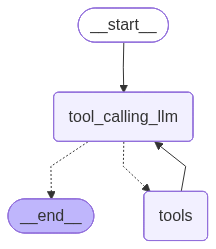

In [38]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (7e2730f0-ec89-462e-bb2a-ad64e3df441c)
 Call ID: 7e2730f0-ec89-462e-bb2a-ad64e3df441c
  Args:
    query: recent AI news
    topic: news
  multiply (a4560185-6eac-472e-944a-cf06295774e6)
 Call ID: a4560185-6eac-472e-944a-cf06295774e6
  Args:
    b: 10
    a: 5
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.7783298, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "# Axios C-Suite: 3 new AI developm

## Adding Memory In Agentic Graph

In [40]:
response=graph.invoke({"messages":"Hello my name is ahtisham"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is ahtisham
================================== Ai Message ==================================

Hello Ahtisham, how can I help you?


In [41]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I do not know your name. I am a large language model, able to communicate in response to a wide range of prompts and questions, but I have no memory of past interactions.


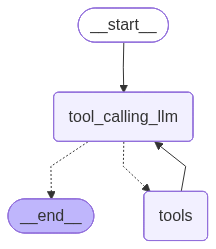

In [42]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [43]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is ahtisham"},config=config)
response['messages'][-1].content

'Hello Ahtisham! How can I help you today?'

In [44]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

[{'type': 'text', 'text': 'Your name is Ahtisham.', 'extras': {'signature': 'CvoBAQw51setOY4U8gQ1D3bf+c0DN3Npg7HoANTzaib1k+Liiu3t4+ITLpek5hXpaz3nRyIrdeFuuiTl4OphBY5D5DibjxNS2PYktK3SpwOK/gVv1p/JTOjX7A6JBLW0155PTImnUeXNFwVSJQjVgKFlYadWo1JXdN0bpYSmVv0DU4wsUtJqDbOYGRaOpEBUfEZopsmuyqJBUvhG+VhZIXHENNgJ6qwjzHsq537o6skyD61+4w5axxS9Zrci3V/RITRjP2g+ZJONsyKOa+kkm+wrkZllMEYi4K55dXHy9q4ZjDtvFfE+N0Omfu0r6MiDoI1taGenwgdkP25qzw=='}}]


In [46]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi my name is ahtisham
================================== Ai Message ==================================

Hello Ahtisham! How can I help you today?
================================ Human Message =================================

Hey what is my name
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Your name is Ahtisham.', 'extras': {'signature': 'CvoBAQw51setOY4U8gQ1D3bf+c0DN3Npg7HoANTzaib1k+Liiu3t4+ITLpek5hXpaz3nRyIrdeFuuiTl4OphBY5D5DibjxNS2PYktK3SpwOK/gVv1p/JTOjX7A6JBLW0155PTImnUeXNFwVSJQjVgKFlYadWo1JXdN0bpYSmVv0DU4wsUtJqDbOYGRaOpEBUfEZopsmuyqJBUvhG+VhZIXHENNgJ6qwjzHsq537o6skyD61+4w5axxS9Zrci3V/RITRjP2g+ZJONsyKOa+kkm+wrkZllMEYi4K55dXHy9q4ZjDtvFfE+N0Omfu0r6MiDoI1taGenwgdkP25qzw=='}}]


In [47]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Yes, your name is Ahtisham.


### Streaming

In [44]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [49]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

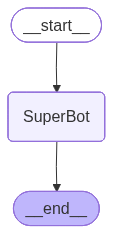

In [50]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [51]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is ahtisham And I like cricket"},config)

{'messages': [HumanMessage(content='Hi my name is ahtisham', additional_kwargs={}, response_metadata={}, id='8df3f60b-c2dc-43ed-b0c0-f766a1a25178'),
  AIMessage(content='Hello Ahtisham! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb643-fc51-7fd3-89bd-82b04308e257-0', usage_metadata={'input_tokens': 1493, 'output_tokens': 12, 'total_tokens': 1505, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='Hey what is my name', additional_kwargs={}, response_metadata={}, id='3ccaa657-9923-4a6a-935c-6ec10594d7d1'),
  AIMessage(content=[{'type': 'text', 'text': 'Your name is Ahtisham.', 'extras': {'signature': 'CvoBAQw51setOY4U8gQ1D3bf+c0DN3Npg7HoANTzaib1k+Liiu3t4+ITLpek5hXpaz3nRyIrdeFuuiTl4OphBY5D5DibjxNS2PYktK3SpwOK/gVv1p/JTOjX7A6JBLW0155PTImnUeXNFwVSJQjVgKFlYadWo1JXdN0bpYSmVv0DU4wsUtJqDbOYGRaOpEBUfEZopsmuyqJBUvhG+VhZIXHENNgJ

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [52]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is ahtisham And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hi Ahtisham! Nice to meet you!\n\nThat's fantastic! Cricket is a truly captivating sport. What aspects of cricket do you enjoy most? Are you a player, a keen spectator of international matches, or do you follow a particular team?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb64d-e985-7cf1-be17-35e6368dbb34-0', usage_metadata={'input_tokens': 13, 'output_tokens': 837, 'total_tokens': 850, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 785}})]}}


In [53]:
for chunk in graph_builder.stream({'messages':"Hi,My name is bilal And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is ahtisham And I like cricket', additional_kwargs={}, response_metadata={}, id='b8844ccf-0dca-417e-a4f1-cea13213ed8b'), AIMessage(content="Hi Ahtisham! Nice to meet you!\n\nThat's fantastic! Cricket is a truly captivating sport. What aspects of cricket do you enjoy most? Are you a player, a keen spectator of international matches, or do you follow a particular team?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb64d-e985-7cf1-be17-35e6368dbb34-0', usage_metadata={'input_tokens': 13, 'output_tokens': 837, 'total_tokens': 850, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 785}}), HumanMessage(content='Hi,My name is bilal And I like cricket', additional_kwargs={}, response_metadata={}, id='5815af43-a02f-4e59-bba3-8524296c7da7')]}


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 42.375827691s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [54]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is ahtisham And I like cricket', additional_kwargs={}, response_metadata={}, id='b8844ccf-0dca-417e-a4f1-cea13213ed8b'), AIMessage(content="Hi Ahtisham! Nice to meet you!\n\nThat's fantastic! Cricket is a truly captivating sport. What aspects of cricket do you enjoy most? Are you a player, a keen spectator of international matches, or do you follow a particular team?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb64d-e985-7cf1-be17-35e6368dbb34-0', usage_metadata={'input_tokens': 13, 'output_tokens': 837, 'total_tokens': 850, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 785}}), HumanMessage(content='Hi,My name is bilal And I like cricket', additional_kwargs={}, response_metadata={}, id='5815af43-a02f-4e59-bba3-8524296c7da7'), HumanMessage(content='I also like football', addition

In [56]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is ahtisham"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is ahtisham']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019eb654-dc6c-71a1-b13d-5569457ae3a8', 'metadata': {'thread_id': '5'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is ahtisham', additional_kwargs={}, response_metadata={}, id='ddebadfa-21cb-4150-a04d-a18f93bc820c'), HumanMessage(content='Hi My name is ahtisham', additional_kwargs={}, response_metadata={}, id='1ef80418-7dd8-4fd4-b4d5-9524e7d49cff')]}}, 'name': 'SuperBot', 'tags': ['graph:step:3'], 'run_id': '019eb654-dc7d-7db0-a88d-a8607cac17eb', 'metadata': {'thread_id': '5', 'langgraph_step': 3, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:6671f7f6-934e-02c4-d601-da0235898eaa'}, 'parent_ids': ['019eb654-dc6c-71a1-b13d-5569457ae3a8']}
{'event': 'on_chat_model_start', 'data